A. Demographics EDA

In [55]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

In [56]:
# load data to df
df = pd.read_csv(
    r"C:\Users\papak\_Study\DSI\ds_team2_bank_marketing\data\raw\bank-additional-full.csv",
    sep = ";" # specify semicolon as separater
)

# display first 10 rows of df
#df.head(10)

#### Question 1: Which age groups are most likely to subscribe to a term deposit?

C:\Users\papak\AppData\Local\Temp\ipykernel_240\2329107281.py:26: FutureWarning:



The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.




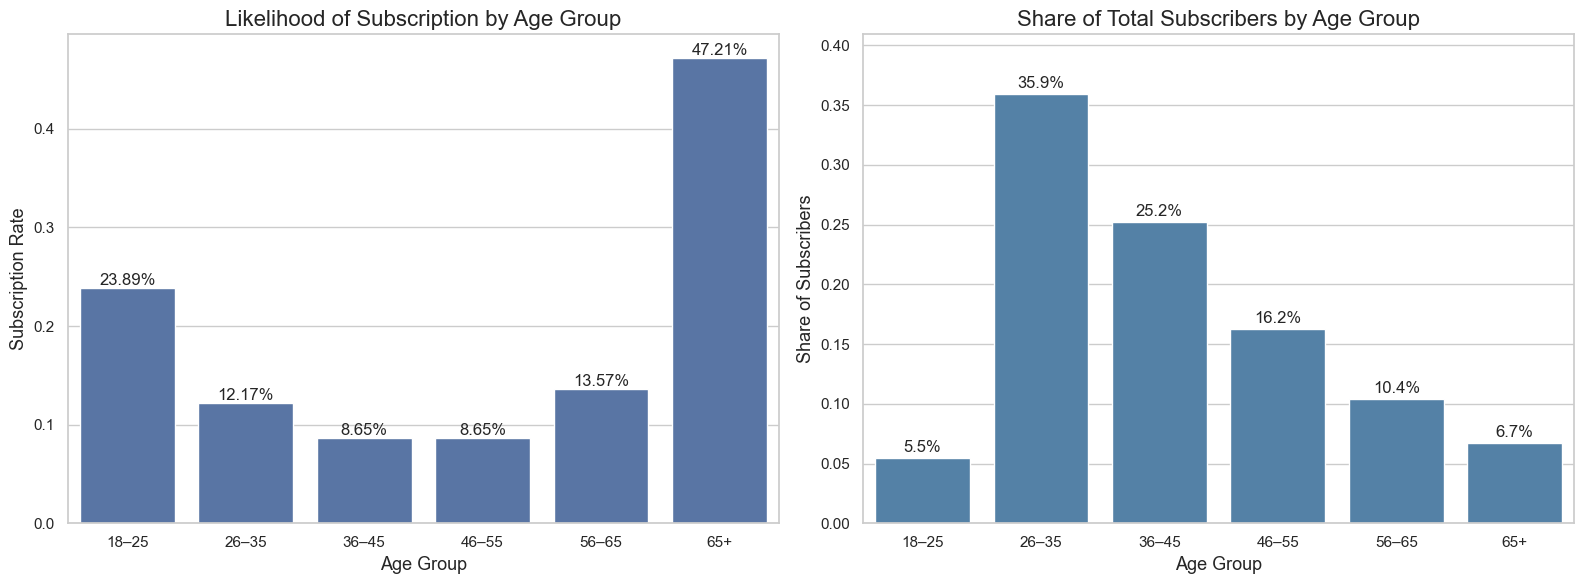

In [57]:
#----------------------------------------
# Create age bins
#----------------------------------------
bins = [18, 25, 35, 45, 55, 65, 100]
labels = ['18–25', '26–35', '36–45', '46–55', '56–65', '65+']
df['age_group'] = pd.cut(df['age'], bins=bins, labels=labels, right=False)

#----------------------------------------
# Prepare data
#----------------------------------------
df['subscribed'] = df['y'].apply(lambda x: 1 if x == 'yes' else 0)

subscriber_volume = (
    df[df['y'] == 'yes']['age_group']
    .value_counts(normalize=True)
    .sort_index()
)

#----------------------------------------
# Side-by-side plots
#----------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Plot 1: Subscription Rate by Age Group ---
ax1 = axes[0]
sns.barplot(
    data=df,
    x='age_group',
    y='subscribed',
    ci=None,
    ax=ax1
)

for p in ax1.patches:
    ax1.annotate(f"{p.get_height():.2%}",
                 (p.get_x() + p.get_width() / 2., p.get_height()),
                 ha='center', va='bottom')

ax1.set_title("Likelihood of Subscription by Age Group")
ax1.set_xlabel("Age Group")
ax1.set_ylabel("Subscription Rate")

# --- Plot 2: Share of All Subscribers by Age Group ---
ax2 = axes[1]
sns.barplot(
    x=subscriber_volume.index,
    y=subscriber_volume.values,
    color='steelblue',
    ax=ax2
)

ax2.set_title("Share of Total Subscribers by Age Group")
ax2.set_xlabel("Age Group")
ax2.set_ylabel("Share of Subscribers")
ax2.set_ylim(0, subscriber_volume.max() + 0.05)

for i, v in enumerate(subscriber_volume.values):
    ax2.text(i, v + 0.005, f"{v:.1%}", ha='center')

plt.tight_layout()
plt.show()



> Result:
> - Age 65+ customers has higher conversion rate/potention
> - Age 26-45 is a larger group of subscribers but have low responsiveness

In [58]:
import pandas as pd
import plotly.express as px

# --- Prepare data ---
df['y_binary'] = df['y'].apply(lambda x: 1 if x=='yes' else 0)

# Likelihood table
likelihood = df.groupby('age_group')['y_binary'].mean().reset_index()
likelihood.rename(columns={'y_binary': 'likelihood'}, inplace=True)

# Volume table (share of all subscribers)
subscriber_counts = df[df['y'] == 'yes'].groupby('age_group').size().reset_index(name='subscriber_count')
total_subscribers = subscriber_counts['subscriber_count'].sum()
subscriber_counts['volume_share'] = subscriber_counts['subscriber_count'] / total_subscribers

# Sample size table
sample_size = df.groupby('age_group').size().reset_index(name='sample_size')

# Merge all metrics
merged = likelihood.merge(subscriber_counts, on='age_group', how='left')
merged = merged.merge(sample_size, on='age_group', how='left')
merged['volume_share'] = merged['volume_share'].fillna(0)

# --- Compute thresholds ---
likelihood_threshold = merged['likelihood'].median()
volume_threshold = merged['volume_share'].median()

# --- Assign quadrant labels ---
def classify_quadrant(row):
    if row['volume_share'] >= volume_threshold and row['likelihood'] >= likelihood_threshold:
        return "Prime Target"
    elif row['volume_share'] >= volume_threshold and row['likelihood'] < likelihood_threshold:
        return "Improvement Opportunity"
    elif row['volume_share'] < volume_threshold and row['likelihood'] >= likelihood_threshold:
        return "Niche / Unstable"
    else:
        return "Low Priority"

merged['quadrant'] = merged.apply(classify_quadrant, axis=1)

# --- Quadrant color map ---
quadrant_colors = {
    "Prime Target": "#2ca02c",             # green
    "Improvement Opportunity": "#ff7f0e",  # orange
    "Niche / Unstable": "#d62728",         # red
    "Low Priority": "#1f77b4"              # blue
}

# --- Base scatter ---
fig = px.scatter(
    merged,
    x='volume_share',
    y='likelihood',
    color='quadrant',
    size='sample_size',
    hover_data={
        "age_group": True,
        "likelihood": ":.2%",
        "volume_share": ":.2%",
        "sample_size": True,
        "subscriber_count": True,
        "quadrant": True
    },
    title="Age Target Matrix: Subscription Likelihood vs Subscriber Volume",
    labels={'volume_share': 'Share of All Subscribers', 'likelihood': 'Subscription Likelihood'},
    size_max=55,
    color_discrete_map=quadrant_colors
)

# Add quadrant reference lines
fig.add_hline(y=likelihood_threshold, line_dash="dash", line_color="gray")
fig.add_vline(x=volume_threshold, line_dash="dash", line_color="gray")

fig.update_layout(width=900, height=650, legend_title_text="Segment Type")

# --- Quadrant labels ---
x_min, x_max = merged['volume_share'].min(), merged['volume_share'].max()
y_min, y_max = merged['likelihood'].min(), merged['likelihood'].max()

x_left  = (x_min + volume_threshold) / 2
x_right = (volume_threshold + x_max) / 2
y_bottom = (y_min + likelihood_threshold) / 2
y_top    = (likelihood_threshold + y_max) / 2

fig.add_annotation(x=x_right, y=y_top, text="Prime Target", showarrow=False, font=dict(size=14, color="#2ca02c"))
fig.add_annotation(x=x_right, y=y_bottom, text="Improvement Opportunity", showarrow=False, font=dict(size=14, color="#ff7f0e"))
fig.add_annotation(x=x_left, y=y_top, text="Niche / Unstable", showarrow=False, font=dict(size=14, color="#d62728"))
fig.add_annotation(x=x_left, y=y_bottom, text="Low Priority", showarrow=False, font=dict(size=14, color="#1f77b4"))

# --- Bubble labels ---
for _, row in merged.iterrows():

    label_text = (
        f"<b>{row['age_group']}</b><br>"
        f"Lik: {row['likelihood']:.1%}<br>"
        f"Vol: {row['volume_share']:.1%}"
    )

    if row['volume_share'] < volume_threshold:
        xanchor = "right"
        xshift = -10
    else:
        xanchor = "left"
        xshift = 10

    fig.add_annotation(
        x=row['volume_share'],
        y=row['likelihood'],
        text=label_text,
        showarrow=False,
        font=dict(size=11, color="black"),
        align="left",
        xanchor=xanchor,
        yanchor="middle",
        xshift=xshift,
        bgcolor="rgba(255,255,255,0.75)",
        bordercolor="rgba(0,0,0,0.25)",
        borderwidth=1,
        borderpad=3
    )

fig.show()


C:\Users\papak\AppData\Local\Temp\ipykernel_240\21399143.py:8: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.

C:\Users\papak\AppData\Local\Temp\ipykernel_240\21399143.py:12: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.

C:\Users\papak\AppData\Local\Temp\ipykernel_240\21399143.py:17: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



> Age by itself does not provide a reliable basis for targeting
> The mismatch between likelihood and volume shows that age alone cannot identify high-value segment without considering other factors like job, education, or marital status

#### Question 2: Are retired customers more likely to subscribe than working professionals?

C:\Users\papak\AppData\Local\Temp\ipykernel_240\3797305224.py:31: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.


C:\Users\papak\AppData\Local\Temp\ipykernel_240\3797305224.py:41: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.

C:\Users\papak\AppData\Local\Temp\ipykernel_240\3797305224.py:51: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.


C:\Users\papak\AppData\Local\Temp\ipykernel_240\3797305224.py:61: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.



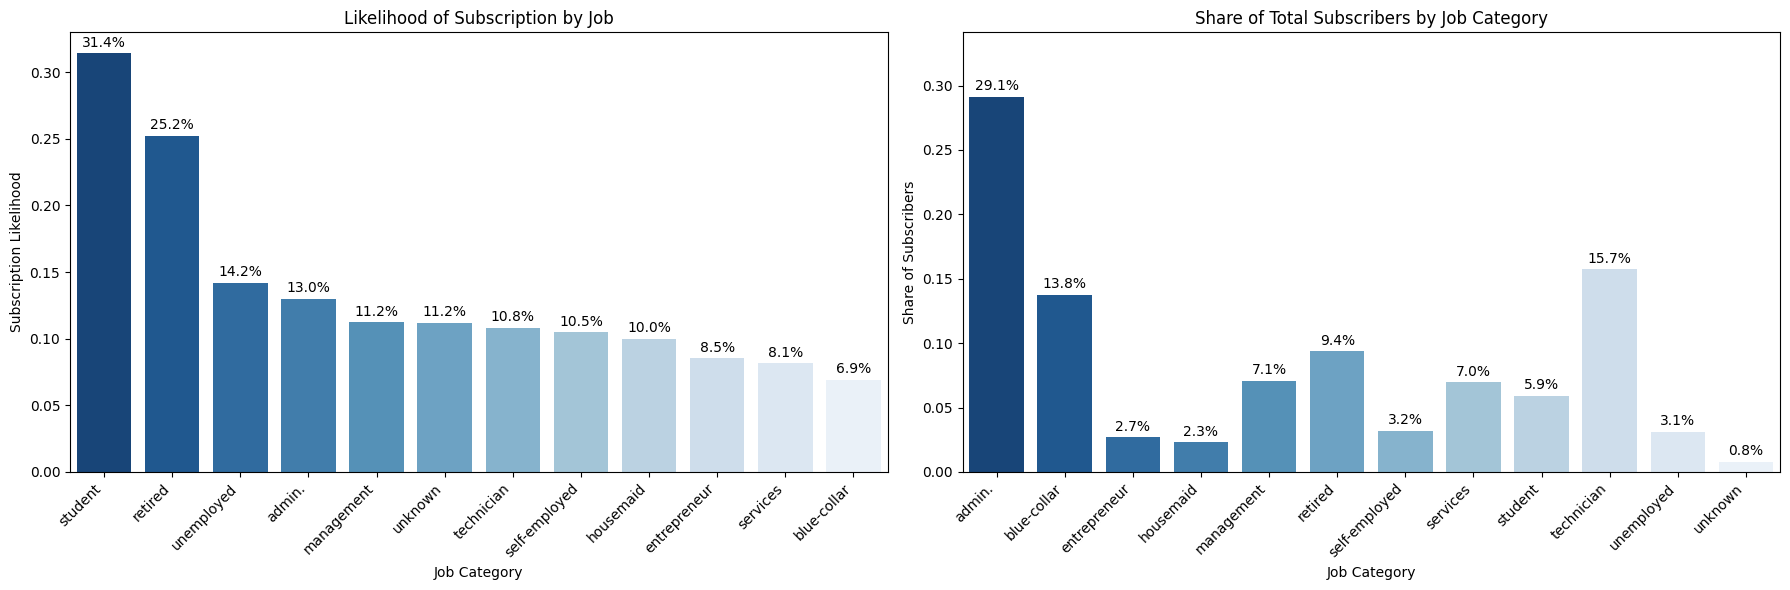

In [30]:
# Convert y to binary
df['y_binary'] = df['y'].apply(lambda x: 1 if x == 'yes' else 0)

#-------------------------
# Compute likelihood
#-------------------------
likelihood = (
    df.groupby('job')['y_binary']
    .mean()
    .sort_values(ascending=False)
)

#-------------------------
# Compute volume
#-------------------------
volume = (
    df[df['y'] == 'yes']['job']
    .value_counts(normalize=True)
    .sort_index()
)

#-------------------------
# Side-by-side plots
#-------------------------
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

#----------------------------------------
# Plot 1: Likelihood of Subscription
#----------------------------------------
ax1 = axes[0]
sns.barplot(
    x=likelihood.index,
    y=likelihood.values,
    ax=ax1,
    palette="Blues_r"
)

ax1.set_title("Likelihood of Subscription by Job")
ax1.set_xlabel("Job Category")
ax1.set_ylabel("Subscription Likelihood")
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45, ha='right')

# Accurate percentage labels
for i, v in enumerate(likelihood.values):
    ax1.text(i, v + 0.005, f"{v:.1%}", ha='center')

#----------------------------------------
# Plot 2: Volume of Subscribers
#----------------------------------------
ax2 = axes[1]
sns.barplot(
    x=volume.index,
    y=volume.values,
    ax=ax2,
    palette="Blues_r"
)

ax2.set_title("Share of Total Subscribers by Job Category")
ax2.set_xlabel("Job Category")
ax2.set_ylabel("Share of Subscribers")
ax2.set_xticklabels(ax2.get_xticklabels(), rotation=45, ha='right')
ax2.set_ylim(0, volume.max() + 0.05)

# Percentage labels
for i, v in enumerate(volume.values):
    ax2.text(i, v + 0.005, f"{v:.1%}", ha='center')

plt.tight_layout()
plt.show()


> Summary:
> - Students and Retired customers are high-likelihood segments but not the largest groups 
> - Admin, Technician, and Blue-collar are large groups, but only Admin and Technician have moderdate likelihood
>    - Blue-color remains low-likelihood
> - Unemployed customers show surprisely high likelihood relative to their size

In [59]:
import pandas as pd
import plotly.express as px

# --- Prepare data ---
df['y_binary'] = df['y'].apply(lambda x: 1 if x=='yes' else 0)

# Likelihood table
likelihood = (
    df.groupby('job')['y_binary']
    .mean()
    .reset_index()
    .rename(columns={'y_binary': 'likelihood'})
)

# Volume table (share of all subscribers)
subscriber_counts = (
    df[df['y'] == 'yes']
    .groupby('job')
    .size()
    .reset_index(name='subscriber_count')
)

total_subscribers = subscriber_counts['subscriber_count'].sum()
subscriber_counts['volume_share'] = subscriber_counts['subscriber_count'] / total_subscribers

# Sample size table
sample_size = df.groupby('job').size().reset_index(name='sample_size')

# Merge all metrics
merged = likelihood.merge(subscriber_counts, on='job', how='left')
merged = merged.merge(sample_size, on='job', how='left')
merged['volume_share'] = merged['volume_share'].fillna(0)

# --- Compute thresholds ---
likelihood_threshold = merged['likelihood'].median()
volume_threshold = merged['volume_share'].median()

# --- Assign quadrant labels ---
def classify_quadrant(row):
    if row['volume_share'] >= volume_threshold and row['likelihood'] >= likelihood_threshold:
        return "Prime Target"
    elif row['volume_share'] >= volume_threshold and row['likelihood'] < likelihood_threshold:
        return "Improvement Opportunity"
    elif row['volume_share'] < volume_threshold and row['likelihood'] >= likelihood_threshold:
        return "Niche / Unstable"
    else:
        return "Low Priority"

merged['quadrant'] = merged.apply(classify_quadrant, axis=1)

# --- Quadrant color map ---
quadrant_colors = {
    "Prime Target": "#2ca02c",             # green
    "Improvement Opportunity": "#ff7f0e",  # orange
    "Niche / Unstable": "#d62728",         # red
    "Low Priority": "#1f77b4"              # blue
}

# --- Base scatter ---
fig = px.scatter(
    merged,
    x='volume_share',
    y='likelihood',
    color='quadrant',
    size='sample_size',
    hover_data={
        "job": True,
        "likelihood": ":.2%",
        "volume_share": ":.2%",
        "sample_size": True,
        "subscriber_count": True,
        "quadrant": True
    },
    title="Job Target Matrix: Subscription Likelihood vs Subscriber Volume",
    labels={'volume_share': 'Share of All Subscribers', 'likelihood': 'Subscription Likelihood'},
    size_max=55,
    color_discrete_map=quadrant_colors
)

# Add quadrant reference lines
fig.add_hline(y=likelihood_threshold, line_dash="dash", line_color="gray")
fig.add_vline(x=volume_threshold, line_dash="dash", line_color="gray")

fig.update_layout(width=900, height=650, legend_title_text="Segment Type")

# --- Quadrant labels ---
x_min, x_max = merged['volume_share'].min(), merged['volume_share'].max()
y_min, y_max = merged['likelihood'].min(), merged['likelihood'].max()

x_left  = (x_min + volume_threshold) / 2
x_right = (volume_threshold + x_max) / 2
y_bottom = (y_min + likelihood_threshold) / 2
y_top    = (likelihood_threshold + y_max) / 2

fig.add_annotation(x=x_right, y=y_top, text="Prime Target", showarrow=False, font=dict(size=14, color="#2ca02c"))
fig.add_annotation(x=x_right, y=y_bottom, text="Improvement Opportunity", showarrow=False, font=dict(size=14, color="#ff7f0e"))
fig.add_annotation(x=x_left, y=y_top, text="Niche / Unstable", showarrow=False, font=dict(size=14, color="#d62728"))
fig.add_annotation(x=x_left, y=y_bottom, text="Low Priority", showarrow=False, font=dict(size=14, color="#1f77b4"))

# --- Bubble labels ---
for _, row in merged.iterrows():

    label_text = (
        f"<b>{row['job']}</b><br>"
        f"Lik: {row['likelihood']:.1%}<br>"
        f"Vol: {row['volume_share']:.1%}"
    )

    if row['volume_share'] < volume_threshold:
        xanchor = "right"
        xshift = -10
    else:
        xanchor = "left"
        xshift = 10

    fig.add_annotation(
        x=row['volume_share'],
        y=row['likelihood'],
        text=label_text,
        showarrow=False,
        font=dict(size=11, color="black"),
        align="left",
        xanchor=xanchor,
        yanchor="middle",
        xshift=xshift,
        bgcolor="rgba(255,255,255,0.75)",
        bordercolor="rgba(0,0,0,0.25)",
        borderwidth=1,
        borderpad=3
    )

fig.show()


#### Question 3: Does a customer's age and job jointly infuence the probability of subscription?

C:\Users\papak\AppData\Local\Temp\ipykernel_240\2729571847.py:16: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  likelihood = df.pivot_table(
C:\Users\papak\AppData\Local\Temp\ipykernel_240\2729571847.py:24: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  sample_size = df.pivot_table(


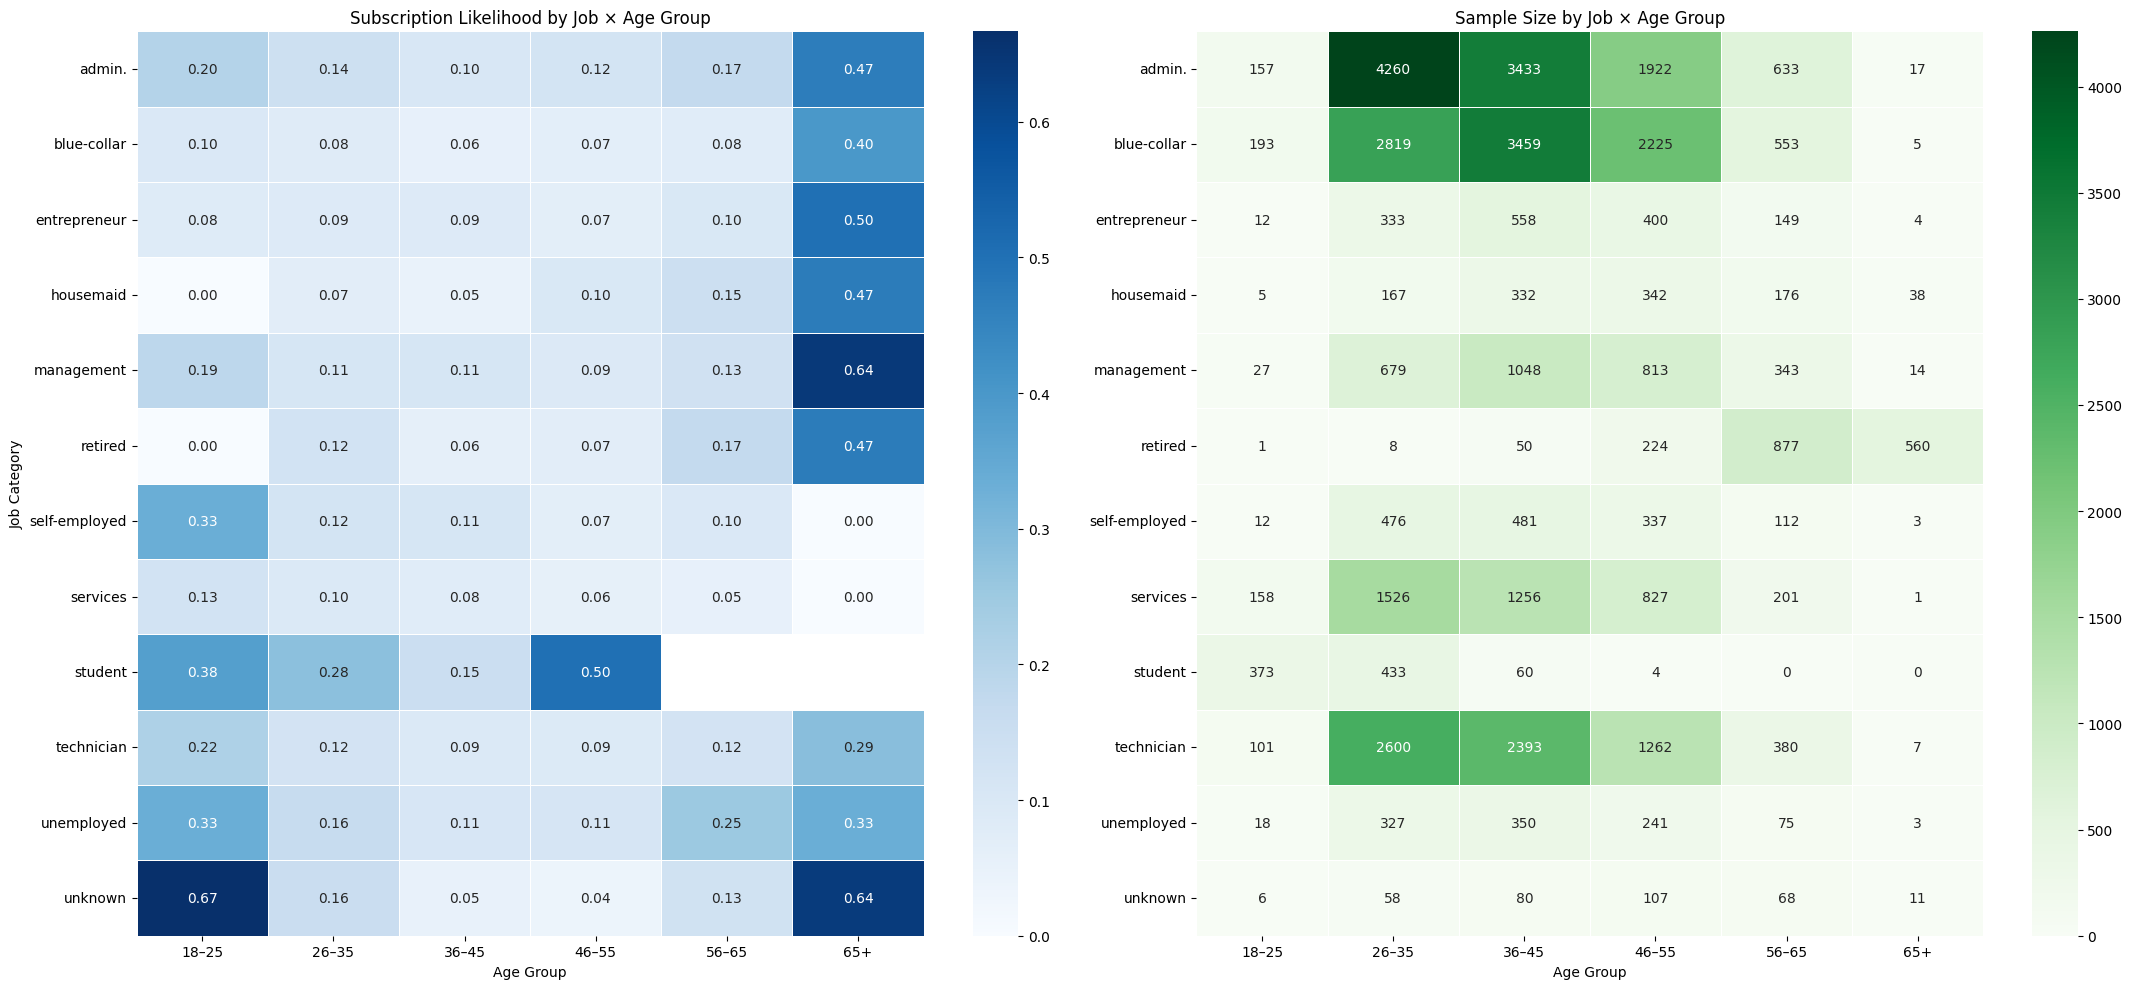

In [ ]:
#-------------------------
#Dual heatmap of likelihood and volume by job and age group
#-------------------------

# --- Prepare data ---

# Age groups
bins = [18, 25, 35, 45, 55, 65, 100]
labels = ['18–25', '26–35', '36–45', '46–55', '56–65', '65+']
df['age_group'] = pd.cut(df['age'], bins=bins, labels=labels, right=False)

# Binary target
df['y_binary'] = df['y'].apply(lambda x: 1 if x=='yes' else 0)

# Likelihood table
likelihood = df.pivot_table(
    values='y_binary',
    index='job',
    columns='age_group',
    aggfunc='mean'
)

# Sample size table
sample_size = df.pivot_table(
    values='y_binary',
    index='job',
    columns='age_group',
    aggfunc='count'
)

# --- Plot dual heatmaps ---

fig, axes = plt.subplots(1, 2, figsize=(22, 10))

# Likelihood heatmap
sns.heatmap(
    likelihood,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    linewidths=.5,
    ax=axes[0]
)
axes[0].set_title("Subscription Likelihood by Job × Age Group")
axes[0].set_xlabel("Age Group")
axes[0].set_ylabel("Job Category")

# Sample size heatmap
sns.heatmap(
    sample_size,
    annot=True,
    fmt="d",
    cmap="Greens",
    linewidths=.5,
    ax=axes[1]
)
axes[1].set_title("Sample Size by Job × Age Group")
axes[1].set_xlabel("Age Group")
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()


> Summary:
- High-value segment (high likelihood+meaningful sample size):
    | Job          | Age Group      |
    |--------------|----------------|
    | Retired      | 56–65, 65+     |
    | Management   | 56–65          |
    | Technician   | 56–65          |
    | Student      | 18–25, 26–35   |


- Improvement Opportunities (large but low-likelihood segments):
    | Job          | Age Group                |
    |--------------|--------------------------|
    | Blue-collar  | 26–35,36–45, 46–55       |
    | Services     | 26–35,36–45, 46–55       |
    | Admin        | 26–35, 36–45             |
    | Technician   | 26–35, 36–45             |

- High-likelihood but tiny segments (statistical noise):
    | Job          | Age Group      |
    |--------------|----------------|
    | Entrepreneur | 65+            |
    | Housemaid    | 65+            |
    | Student      | 46–55          |
    | Unknown      | 18–25, 65+     |

Remarks: threshold used in practice:
* n < 20 → statistical noise (ignore)
* 20 ≤ n < 50 → unstable but usable with caution
* n ≥ 50 → reasonably stable
* n ≥ 200 → very stable and reliable
> Conclusion:
> the heatmap confirms that job and age interact strongly, and the most valuable segments are:
> - older professional groups (management, admin, technician)
> - Retired customers
> - Younger students

> While, blue-collar and services remain low-response across most ages, even though they are large groups

In [ ]:
#-------------------------
# Interactive scatter plot of likelihood vs sample size by job and age group
#-------------------------

import plotly.express as px

# Age groups
bins = [18, 25, 35, 45, 55, 65, 100]
labels = ['18–25', '26–35', '36–45', '46–55', '56–65', '65+']
df['age_group'] = pd.cut(df['age'], bins=bins, labels=labels, right=False)

# Binary target
df['y_binary'] = df['y'].apply(lambda x: 1 if x=='yes' else 0)

# Likelihood table
likelihood = df.pivot_table(
    values='y_binary',
    index='job',
    columns='age_group',
    aggfunc='mean'
)

# Sample size table
sample_size = df.pivot_table(
    values='y',
    index='job',
    columns='age_group',
    aggfunc='count',
    fill_value=0
)

# Melt both tables into long format
likelihood_long = likelihood.reset_index().melt(id_vars='job', var_name='age_group', value_name='likelihood')
sample_long = sample_size.reset_index().melt(id_vars='job', var_name='age_group', value_name='sample_size')

# Merge likelihood + sample size
merged = pd.merge(likelihood_long, sample_long, on=['job', 'age_group'])

# Remove rows with missing likelihood
merged = merged.dropna(subset=['likelihood'])

# --- Compute thresholds ---
likelihood_threshold = merged['likelihood'].median()
sample_threshold = merged['sample_size'].median()

# --- Assign quadrant labels ---
def classify_quadrant(row):
    if row['sample_size'] >= sample_threshold and row['likelihood'] >= likelihood_threshold:
        return "Prime Target"
    elif row['sample_size'] >= sample_threshold and row['likelihood'] < likelihood_threshold:
        return "Improvement Opportunity"
    elif row['sample_size'] < sample_threshold and row['likelihood'] >= likelihood_threshold:
        return "Niche / Unstable"
    else:
        return "Low Priority"

merged['quadrant'] = merged.apply(classify_quadrant, axis=1)

# --- Interactive scatter plot ---
fig = px.scatter(
    merged,
    x='sample_size',
    y='likelihood',
    color='quadrant',
    size='sample_size',
    hover_name='job',
    hover_data={
        'age_group': True,
        'sample_size': True,
        'likelihood': ':.2f',
        'quadrant': True
    },
    title="Interactive Target Matrix: Subscription Likelihood vs Sample Size (Job × Age Group)",
    labels={
        'sample_size': 'Sample Size (Segment Size)',
        'likelihood': 'Subscription Likelihood'
    },
    size_max=40,
    color_discrete_map={
        "Prime Target": "#1f77b4",              # blue
        "Improvement Opportunity": "#ff7f0e",   # orange
        "Niche / Unstable": "#2ca02c",          # green
        "Low Priority": "#d62728"               # red
    }
)

# Add quadrant reference lines
fig.add_hline(y=likelihood_threshold, line_dash="dash", line_color="gray")
fig.add_vline(x=sample_threshold, line_dash="dash", line_color="gray")

fig.update_layout(
    width=1000,
    height=700,
    legend_title_text="Segment Type"
)

# --- Compute quadrant midpoints for centered labels ---
x_min, x_max = merged['sample_size'].min(), merged['sample_size'].max()
y_min, y_max = merged['likelihood'].min(), merged['likelihood'].max()

x_left  = (x_min + sample_threshold) / 2
x_right = (sample_threshold + x_max) / 2
y_bottom = (y_min + likelihood_threshold) / 2
y_top    = (likelihood_threshold + y_max) / 2

# --- Add quadrant shading (background rectangles) ---
fig.add_shape(type="rect",
              x0=x_min, x1=sample_threshold,
              y0=y_min, y1=likelihood_threshold,
              fillcolor="rgba(214, 39, 40, 0.08)", line_width=0)

fig.add_shape(type="rect",
              x0=sample_threshold, x1=x_max,
              y0=y_min, y1=likelihood_threshold,
              fillcolor="rgba(255, 127, 14, 0.08)", line_width=0)

fig.add_shape(type="rect",
              x0=x_min, x1=sample_threshold,
              y0=likelihood_threshold, y1=y_max,
              fillcolor="rgba(44, 160, 44, 0.08)", line_width=0)

fig.add_shape(type="rect",
              x0=sample_threshold, x1=x_max,
              y0=likelihood_threshold, y1=y_max,
              fillcolor="rgba(31, 119, 180, 0.08)", line_width=0)

# --- Add centered quadrant labels ---
fig.add_annotation(
    x=x_right, y=y_top,
    text="Prime Target<br>High likelihood & Large sample",
    showarrow=False, font=dict(size=13, color="black")
)

fig.add_annotation(
    x=x_right, y=y_bottom,
    text="Improvement Opportunity<br>Low likelihood & Large sample",
    showarrow=False, font=dict(size=13, color="black")
)

fig.add_annotation(
    x=x_left, y=y_top,
    text="Niche / Unstable<br>High likelihood & Small sample",
    showarrow=False, font=dict(size=13, color="black")
)

fig.add_annotation(
    x=x_left, y=y_bottom,
    text="Low Priority<br>Low likelihood & Small sample",
    showarrow=False, font=dict(size=13, color="black")
)

fig.show()


C:\Users\papak\AppData\Local\Temp\ipykernel_240\2660065355.py:15: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  likelihood = df.pivot_table(
C:\Users\papak\AppData\Local\Temp\ipykernel_240\2660065355.py:23: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  sample_size = df.pivot_table(


#### Question 4: Does a customer's education level impact subscription?

C:\Users\papak\AppData\Local\Temp\ipykernel_240\3437074427.py:40: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.


C:\Users\papak\AppData\Local\Temp\ipykernel_240\3437074427.py:52: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.

C:\Users\papak\AppData\Local\Temp\ipykernel_240\3437074427.py:74: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.



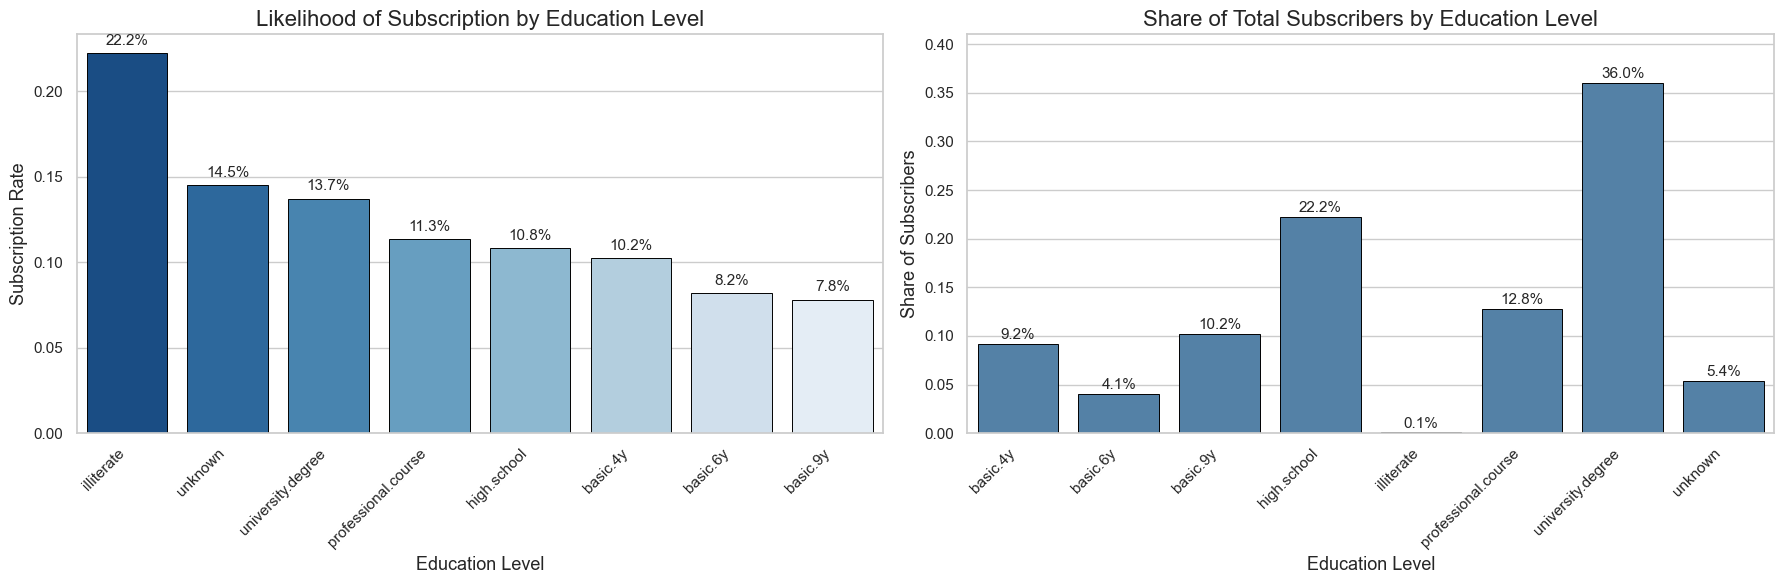

In [31]:
# Convert y to binary
df['y_binary'] = df['y'].apply(lambda x: 1 if x == 'yes' else 0)

#-------------------------
# Compute likelihood
#-------------------------
edu_likelihood = (
    df.groupby('education')['y_binary']
    .mean()
    .sort_values(ascending=False)
)

#-------------------------
# Compute volume
#-------------------------
edu_volume = (
    df[df['y'] == 'yes']['education']
    .value_counts(normalize=True)
    .sort_index()
)

#-------------------------
# Styling
#-------------------------
sns.set_theme(style="whitegrid")
plt.rcParams['axes.titlesize'] = 16
plt.rcParams['axes.labelsize'] = 13
plt.rcParams['xtick.labelsize'] = 11
plt.rcParams['ytick.labelsize'] = 11

#-------------------------
# Side-by-side plots
#-------------------------
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

#----------------------------------------
# Plot 1: Likelihood of Subscription
#----------------------------------------
ax1 = axes[0]
sns.barplot(
    x=edu_likelihood.index,
    y=edu_likelihood.values,
    ax=ax1,
    palette="Blues_r",
    edgecolor="black",
    linewidth=0.7
)

ax1.set_title("Likelihood of Subscription by Education Level")
ax1.set_xlabel("Education Level")
ax1.set_ylabel("Subscription Rate")
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45, ha='right')

# Percentage labels
for i, v in enumerate(edu_likelihood.values):
    ax1.text(i, v + 0.005, f"{v:.1%}", ha='center', fontsize=11)

#----------------------------------------
# Plot 2: Volume of Subscribers
#----------------------------------------
ax2 = axes[1]
sns.barplot(
    x=edu_volume.index,
    y=edu_volume.values,
    ax=ax2,
    color="steelblue",
    edgecolor="black",
    linewidth=0.7
)

ax2.set_title("Share of Total Subscribers by Education Level")
ax2.set_xlabel("Education Level")
ax2.set_ylabel("Share of Subscribers")
ax2.set_xticklabels(ax2.get_xticklabels(), rotation=45, ha='right')
ax2.set_ylim(0, edu_volume.max() + 0.05)

# Percentage labels
for i, v in enumerate(edu_volume.values):
    ax2.text(i, v + 0.005, f"{v:.1%}", ha='center', fontsize=11)

plt.tight_layout()
plt.show()


> - Less-educated customers tend to be more responsive to term deposit offers
>   - Illiterate/unknown grpus are extremely small --> likelihood is inflated by small sample size --> result is not representable
> - University-degree customers have a high likelihood and largest share of total subscribers
>   - this group is both large and responsive
> - Though High-school and professional course groups has moderate responsiveness, but they contribute a large share of subscribers

In [19]:
import pandas as pd
import plotly.express as px

# --- Prepare data ---

df['y_binary'] = df['y'].apply(lambda x: 1 if x=='yes' else 0)

likelihood = df.groupby('education')['y_binary'].mean().reset_index()
likelihood.rename(columns={'y_binary': 'likelihood'}, inplace=True)

subscriber_counts = df[df['y'] == 'yes'].groupby('education').size().reset_index(name='subscriber_count')
total_subscribers = subscriber_counts['subscriber_count'].sum()
subscriber_counts['volume_share'] = subscriber_counts['subscriber_count'] / total_subscribers

merged = pd.merge(likelihood, subscriber_counts, on='education', how='left')
merged['volume_share'] = merged['volume_share'].fillna(0)

# --- Thresholds ---
likelihood_threshold = merged['likelihood'].median()
volume_threshold = merged['volume_share'].median()

# --- Quadrants ---
def classify_quadrant(row):
    if row['volume_share'] >= volume_threshold and row['likelihood'] >= likelihood_threshold:
        return "Prime Target"
    elif row['volume_share'] >= volume_threshold and row['likelihood'] < likelihood_threshold:
        return "Improvement Opportunity"
    elif row['volume_share'] < volume_threshold and row['likelihood'] >= likelihood_threshold:
        return "Niche / Unstable"
    else:
        return "Low Priority"

merged['quadrant'] = merged.apply(classify_quadrant, axis=1)

# --- Base scatter ---
fig = px.scatter(
    merged,
    x='volume_share',
    y='likelihood',
    color='quadrant',
    size='volume_share',
    hover_data={},  # disable hover
    title="Education Target Matrix: Subscription Likelihood vs Subscriber Volume",
    labels={'volume_share': 'Share of All Subscribers', 'likelihood': 'Subscription Likelihood'},
    size_max=40,
    color_discrete_map={
        "Prime Target": "#1f77b4",
        "Improvement Opportunity": "#ff7f0e",
        "Niche / Unstable": "#2ca02c",
        "Low Priority": "#d62728"
    }
)

fig.add_hline(y=likelihood_threshold, line_dash="dash", line_color="gray")
fig.add_vline(x=volume_threshold, line_dash="dash", line_color="gray")

fig.update_layout(width=900, height=650, legend_title_text="Segment Type")

# --- Quadrant shading ---
x_min, x_max = merged['volume_share'].min(), merged['volume_share'].max()
y_min, y_max = merged['likelihood'].min(), merged['likelihood'].max()

fig.add_shape(type="rect", x0=x_min, x1=volume_threshold, y0=y_min, y1=likelihood_threshold,
              fillcolor="rgba(214, 39, 40, 0.08)", line_width=0)
fig.add_shape(type="rect", x0=volume_threshold, x1=x_max, y0=y_min, y1=likelihood_threshold,
              fillcolor="rgba(255, 127, 14, 0.08)", line_width=0)
fig.add_shape(type="rect", x0=x_min, x1=volume_threshold, y0=likelihood_threshold, y1=y_max,
              fillcolor="rgba(44, 160, 44, 0.08)", line_width=0)
fig.add_shape(type="rect", x0=volume_threshold, x1=x_max, y0=likelihood_threshold, y1=y_max,
              fillcolor="rgba(31, 119, 180, 0.08)", line_width=0)

# --- Quadrant labels ---
x_left  = (x_min + volume_threshold) / 2
x_right = (volume_threshold + x_max) / 2
y_bottom = (y_min + likelihood_threshold) / 2
y_top    = (likelihood_threshold + y_max) / 2

fig.add_annotation(x=x_right, y=y_top, text="Prime Target", showarrow=False, font=dict(size=14))
fig.add_annotation(x=x_right, y=y_bottom, text="Improvement Opportunity", showarrow=False, font=dict(size=14))
fig.add_annotation(x=x_left, y=y_top, text="Niche / Unstable", showarrow=False, font=dict(size=14))
fig.add_annotation(x=x_left, y=y_bottom, text="Low Priority", showarrow=False, font=dict(size=14))

# --- Improved bubble labels ---
for _, row in merged.iterrows():

    # Bold education name + short metrics
    label_text = (
        f"<b>{row['education']}</b><br>"
        f"Lik: {row['likelihood']:.2f} | Vol: {row['volume_share']:.2f}"
    )

    # Smart label placement: right side for left quadrants, left side for right quadrants
    if row['volume_share'] < volume_threshold:
        xanchor = "right"
        xshift = -10
    else:
        xanchor = "left"
        xshift = 10

    fig.add_annotation(
        x=row['volume_share'],
        y=row['likelihood'],
        text=label_text,
        showarrow=False,
        font=dict(size=11, color="black"),
        align="left",
        xanchor=xanchor,
        yanchor="middle",
        xshift=xshift,
        bgcolor="rgba(255,255,255,0.7)",  # readable background
        bordercolor="rgba(0,0,0,0.2)",
        borderwidth=1,
        borderpad=3
    )

fig.show()


> Summary: Yes, education level impacts subscription, but in 2 different ways:
> - Likelihood decreases as education increases
> - Volume increases as education increases

#### Question 5: How does marital status impact subscription behavior?

C:\Users\papak\AppData\Local\Temp\ipykernel_240\4202943735.py:40: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.


C:\Users\papak\AppData\Local\Temp\ipykernel_240\4202943735.py:52: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.

C:\Users\papak\AppData\Local\Temp\ipykernel_240\4202943735.py:74: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.



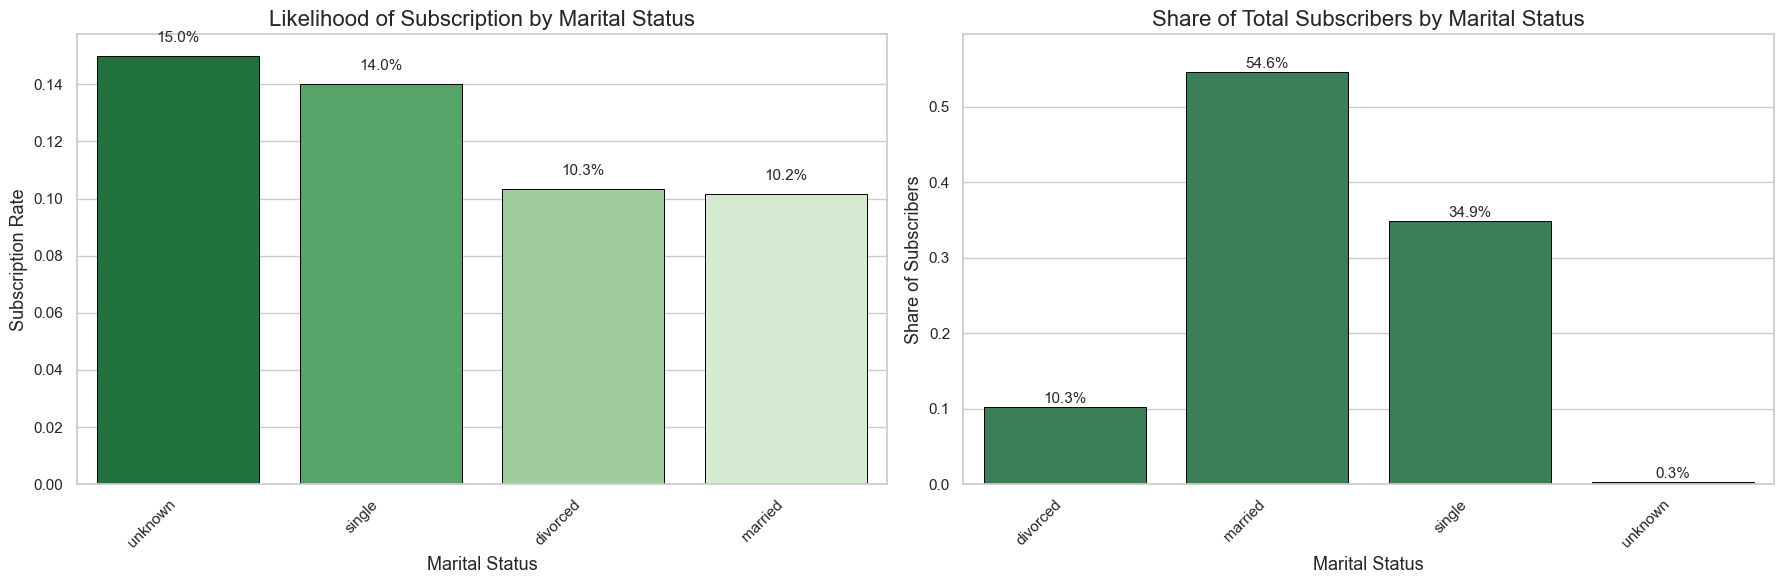

In [32]:
# Convert y to binary (if not already done)
df['y_binary'] = df['y'].apply(lambda x: 1 if x == 'yes' else 0)

#-------------------------
# Compute likelihood
#-------------------------
marital_likelihood = (
    df.groupby('marital')['y_binary']
    .mean()
    .sort_values(ascending=False)
)

#-------------------------
# Compute volume
#-------------------------
marital_volume = (
    df[df['y'] == 'yes']['marital']
    .value_counts(normalize=True)
    .sort_index()
)

#-------------------------
# Styling
#-------------------------
sns.set_theme(style="whitegrid")
plt.rcParams['axes.titlesize'] = 16
plt.rcParams['axes.labelsize'] = 13
plt.rcParams['xtick.labelsize'] = 11
plt.rcParams['ytick.labelsize'] = 11

#-------------------------
# Side-by-side plots
#-------------------------
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

#----------------------------------------
# Plot 1: Likelihood of Subscription
#----------------------------------------
ax1 = axes[0]
sns.barplot(
    x=marital_likelihood.index,
    y=marital_likelihood.values,
    ax=ax1,
    palette="Greens_r",
    edgecolor="black",
    linewidth=0.7
)

ax1.set_title("Likelihood of Subscription by Marital Status")
ax1.set_xlabel("Marital Status")
ax1.set_ylabel("Subscription Rate")
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45, ha='right')

# Percentage labels
for i, v in enumerate(marital_likelihood.values):
    ax1.text(i, v + 0.005, f"{v:.1%}", ha='center', fontsize=11)

#----------------------------------------
# Plot 2: Volume of Subscribers
#----------------------------------------
ax2 = axes[1]
sns.barplot(
    x=marital_volume.index,
    y=marital_volume.values,
    ax=ax2,
    color="seagreen",
    edgecolor="black",
    linewidth=0.7
)

ax2.set_title("Share of Total Subscribers by Marital Status")
ax2.set_xlabel("Marital Status")
ax2.set_ylabel("Share of Subscribers")
ax2.set_xticklabels(ax2.get_xticklabels(), rotation=45, ha='right')
ax2.set_ylim(0, marital_volume.max() + 0.05)

# Percentage labels
for i, v in enumerate(marital_volume.values):
    ax2.text(i, v + 0.005, f"{v:.1%}", ha='center', fontsize=11)

plt.tight_layout()
plt.show()


> Singles are meaningfully more responsive than married or divorced customers, it also contribute a large share of total subscribers
> - Single individuals may be more open to financial products or more reachable by marketing channels

Though married customers have the lowest likelihood, they dominate total subscriber volume simply because they are the largest population group


>The 'unknown' group is small and unstable - its high rate is likely due to small sample size or data quality issues

In [22]:
import pandas as pd 
import plotly.express as px 
# --- Prepare data ---
df['y_binary'] = df['y'].apply(lambda x: 1 if x=='yes' else 0)
# Likelihood table
likelihood = df.groupby('marital')['y_binary'].mean().reset_index()
likelihood.rename(columns={'y_binary': 'likelihood'}, inplace=True)

# Volume table (share of all subscribers)
subscriber_counts = df[df['y'] == 'yes'].groupby('marital').size().reset_index(name='subscriber_count')
total_subscribers = subscriber_counts['subscriber_count'].sum()
subscriber_counts['volume_share'] = subscriber_counts['subscriber_count'] / total_subscribers

# Merge likelihood + volume
merged = pd.merge(likelihood, subscriber_counts, on='marital', how='left')
merged['volume_share'] = merged['volume_share'].fillna(0)

# --- Compute thresholds ---
likelihood_threshold = merged['likelihood'].median()
volume_threshold = merged['volume_share'].median()

# --- Assign quadrant labels ---
def classify_quadrant(row):
    if row['volume_share'] >= volume_threshold and row['likelihood'] >= likelihood_threshold:
        return "Prime Target"
    elif row['volume_share'] >= volume_threshold and row['likelihood'] < likelihood_threshold:
        return "Improvement Opportunity"
    elif row['volume_share'] < volume_threshold and row['likelihood'] >= likelihood_threshold:
        return "Niche / Unstable"
    else:
        return "Low Priority"

merged['quadrant'] = merged.apply(classify_quadrant, axis=1)

# --- Base scatter ---
fig = px.scatter(
    merged,
    x='volume_share',
    y='likelihood',
    color='quadrant',
    size='volume_share',
    hover_data={},  # disable hover
    title="Marital Status Target Matrix: Subscription Likelihood vs Subscriber Volume",
    labels={'volume_share': 'Share of All Subscribers', 'likelihood': 'Subscription Likelihood'},
    size_max=40,
    color_discrete_map={
        "Prime Target": "#1f77b4",
        "Improvement Opportunity": "#ff7f0e",
        "Niche / Unstable": "#2ca02c",
        "Low Priority": "#d62728"
    }
)

# Add quadrant reference lines
fig.add_hline(y=likelihood_threshold, line_dash="dash", line_color="gray")
fig.add_vline(x=volume_threshold, line_dash="dash", line_color="gray")

fig.update_layout(width=900, height=650, legend_title_text="Segment Type")

# --- Quadrant shading ---
x_min, x_max = merged['volume_share'].min(), merged['volume_share'].max()
y_min, y_max = merged['likelihood'].min(), merged['likelihood'].max()

fig.add_shape(type="rect", x0=x_min, x1=volume_threshold, y0=y_min, y1=likelihood_threshold,
              fillcolor="rgba(214, 39, 40, 0.08)", line_width=0)
fig.add_shape(type="rect", x0=volume_threshold, x1=x_max, y0=y_min, y1=likelihood_threshold,
              fillcolor="rgba(255, 127, 14, 0.08)", line_width=0)
fig.add_shape(type="rect", x0=x_min, x1=volume_threshold, y0=likelihood_threshold, y1=y_max,
              fillcolor="rgba(44, 160, 44, 0.08)", line_width=0)
fig.add_shape(type="rect", x0=volume_threshold, x1=x_max, y0=likelihood_threshold, y1=y_max,
              fillcolor="rgba(31, 119, 180, 0.08)", line_width=0)

# --- Quadrant labels ---
x_left  = (x_min + volume_threshold) / 2
x_right = (volume_threshold + x_max) / 2
y_bottom = (y_min + likelihood_threshold) / 2
y_top    = (likelihood_threshold + y_max) / 2

fig.add_annotation(x=x_right, y=y_top, text="Prime Target", showarrow=False, font=dict(size=14))
fig.add_annotation(x=x_right, y=y_bottom, text="Improvement Opportunity", showarrow=False, font=dict(size=14))
fig.add_annotation(x=x_left, y=y_top, text="Niche / Unstable", showarrow=False, font=dict(size=14))
fig.add_annotation(x=x_left, y=y_bottom, text="Low Priority", showarrow=False, font=dict(size=14))

# --- Improved bubble labels ---
for _, row in merged.iterrows():

    label_text = (
        f"<b>{row['marital']}</b><br>"
        f"Lik: {row['likelihood']:.2f} | Vol: {row['volume_share']:.2f}"
    )

    # Smart label placement
    if row['volume_share'] < volume_threshold:
        xanchor = "right"
        xshift = -10
    else:
        xanchor = "left"
        xshift = 10

    fig.add_annotation(
        x=row['volume_share'],
        y=row['likelihood'],
        text=label_text,
        showarrow=False,
        font=dict(size=11, color="black"),
        align="left",
        xanchor=xanchor,
        yanchor="middle",
        xshift=xshift,
        bgcolor="rgba(255,255,255,0.75)",
        bordercolor="rgba(0,0,0,0.25)",
        borderwidth=1,
        borderpad=3
    )

fig.show()

# Export PNG (requires Kaleido installed)
# fig.write_image("marital_target_matrix.png")


> Results: Yes, marital status impacts subscription behaviour:

> - Singles: most responsive meaningful group
> - Married customers convert less often but dominate total subscribers due to population size
>- Divorced customers are a mid-tier segment with room for improvement

### Additional Summary: 4-factor demographic summary chart

In [23]:
import pandas as pd
import numpy as np

# --- Prepare data ---

# Age groups
bins = [18, 25, 35, 45, 55, 65, 100]
labels = ['18–25', '26–35', '36–45', '46–55', '56–65', '65+']
df['age_group'] = pd.cut(df['age'], bins=bins, labels=labels, right=False)

# Binary target
df['y_binary'] = df['y'].apply(lambda x: 1 if x=='yes' else 0)

# Group by all 4 demographic factors
segment = df.groupby(['age_group', 'job', 'education', 'marital']).agg(
    likelihood=('y_binary', 'mean'),
    volume=('y_binary', 'sum'),
    sample_size=('y_binary', 'count')
).reset_index()

# Remove tiny segments (unstable)
segment = segment[segment['sample_size'] >= 50]

# Priority score = likelihood × log(sample size)
segment['priority_score'] = segment['likelihood'] * np.log(segment['sample_size'] + 1)

# --- Quadrant thresholds ---
likelihood_threshold = segment['likelihood'].median()
sample_threshold = segment['sample_size'].median()

# --- Assign quadrant labels ---
def classify_quadrant(row):
    if row['sample_size'] >= sample_threshold and row['likelihood'] >= likelihood_threshold:
        return "Prime Target"
    elif row['sample_size'] >= sample_threshold and row['likelihood'] < likelihood_threshold:
        return "Improvement Opportunity"
    elif row['sample_size'] < sample_threshold and row['likelihood'] >= likelihood_threshold:
        return "Niche / Unstable"
    else:
        return "Low Priority"

segment['quadrant'] = segment.apply(classify_quadrant, axis=1)

# --- Sort segments within each quadrant ---
segment_sorted = segment.sort_values(
    by=['quadrant', 'priority_score'], ascending=[True, False]
)

# --- Create separate tables for each quadrant ---
prime_target = segment_sorted[segment_sorted['quadrant'] == "Prime Target"]
improvement = segment_sorted[segment_sorted['quadrant'] == "Improvement Opportunity"]
niche = segment_sorted[segment_sorted['quadrant'] == "Niche / Unstable"]
low_priority = segment_sorted[segment_sorted['quadrant'] == "Low Priority"]

# --- Optional: create a single combined table for export ---
summary_table = segment_sorted[[
    'quadrant', 'age_group', 'job', 'education', 'marital',
    'likelihood', 'sample_size', 'priority_score'
]]

summary_table


C:\Users\papak\AppData\Local\Temp\ipykernel_240\3687521816.py:15: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



,quadrant,age_group,job,education,marital,likelihood,sample_size,priority_score
1077,Improvement Opportunity,36–45,technician,professional.course,married,0.095675,763,0.635145
1165,Improvement Opportunity,46–55,admin.,high.school,married,0.098446,386,0.586581
782,Improvement Opportunity,36–45,admin.,high.school,single,0.098551,345,0.576171
781,Improvement Opportunity,36–45,admin.,high.school,married,0.086890,656,0.563716
1461,Improvement Opportunity,46–55,technician,professional.course,married,0.090349,487,0.559289
...,...,...,...,...,...,...,...,...
1176,Prime Target,46–55,admin.,university.degree,divorced,0.102881,243,0.565552
686,Prime Target,26–35,technician,high.school,single,0.104651,172,0.539298
857,Prime Target,36–45,entrepreneur,university.degree,married,0.107383,149,0.538055
780,Prime Target,36–45,admin.,high.school,divorced,0.102703,185,0.536698


In [50]:
import plotly.express as px
import plotly.graph_objects as go
import pandas as pd
import numpy as np

# ---------------------------------------------------------
# 1. QUADRANT BUBBLE CHART (Likelihood vs Sample Size)
# ---------------------------------------------------------

fig1 = px.scatter(
    segment,
    x="sample_size",
    y="likelihood",
    size="volume",
    color="quadrant",
    hover_data=["age_group", "job", "education", "marital", "priority_score"],
    title="Quadrant Bubble Chart: Likelihood vs Sample Size",
    labels={"sample_size": "Sample Size", "likelihood": "Subscription Likelihood"},
    size_max=40
)

fig1.update_layout(
    plot_bgcolor="white",
    xaxis=dict(showgrid=True, gridcolor="lightgrey"),
    yaxis=dict(showgrid=True, gridcolor="lightgrey")
)
fig1.add_annotation(
    x=1.35, y=-0.20, xref="paper", yref="paper",
    text=(
        "Large sample + high likelihood → <b>Prime Targets</b><br>"
        "Large sample + low likelihood → <b>Improvement Opportunities</b><br>"
        "Small sample + high likelihood → <b>Niche</b><br>"
        "Small sample + low likelihood → <b>Low Priority</b>"
    ),
    showarrow=False,
    align="left",
    font=dict(size=12, color="black"),
    bordercolor="lightgrey",
    borderwidth=1,
    borderpad=6,
    bgcolor="white",
    opacity=0.9
)


fig1.show()


# ---------------------------------------------------------
# 2. TREEMAP (Population Structure by 4 Demographics)
# ---------------------------------------------------------

fig2 = px.treemap(
    segment,
    path=["age_group", "job", "education", "marital"],
    values="sample_size",
    color="likelihood",
    color_continuous_scale="Blues",
    title="Treemap: Population Structure by Demographic Layers"
)

fig2.update_layout(margin=dict(t=50, l=25, r=25, b=25))
fig2.show()


# ---------------------------------------------------------
# 3. HEATMAPS (Pairwise Interactions)
# ---------------------------------------------------------

# Age × Job likelihood heatmap
heat_age_job = segment.groupby(["age_group", "job"])["likelihood"].mean().reset_index()
pivot_age_job = heat_age_job.pivot(index="age_group", columns="job", values="likelihood")

fig3 = px.imshow(
    pivot_age_job,
    color_continuous_scale="Viridis",
    title="Heatmap: Likelihood by Age Group × Job",
    labels=dict(color="Likelihood")
)

fig3.update_layout(xaxis=dict(side="top"))
fig3.show()


# Education × Job likelihood heatmap
heat_edu_job = segment.groupby(["education", "job"])["likelihood"].mean().reset_index()
pivot_edu_job = heat_edu_job.pivot(index="education", columns="job", values="likelihood")

fig4 = px.imshow(
    pivot_edu_job,
    color_continuous_scale="Viridis",
    title="Heatmap: Likelihood by Education × Job",
    labels=dict(color="Likelihood")
)

fig4.update_layout(xaxis=dict(side="top"))
fig4.show()


# ---------------------------------------------------------
# 4. TOP PRIME TARGET SEGMENTS (Ranked Bar Chart)
# ---------------------------------------------------------

top_prime = (
    segment[segment["quadrant"] == "Prime Target"]
    .sort_values("priority_score", ascending=False)
    .head(12)
)

top_prime["segment_label"] = (
    top_prime["age_group"].astype(str) + " | " +
    top_prime["job"].astype(str) + " | " +
    top_prime["education"].astype(str) + " | " +
    top_prime["marital"].astype(str)
)

fig5 = px.bar(
    top_prime,
    x="priority_score",
    y="segment_label",
    color="likelihood",
    orientation="h",
    color_continuous_scale="Greens",
    title="Top Prime Target Segments (Ranked by Priority Score)",
    labels={"priority_score": "Priority Score", "segment_label": "Segment"}
)

fig5.update_layout(yaxis=dict(categoryorder="total ascending"))

fig5.add_annotation(
    x=1, y=0, xref="paper", yref="paper",
    text=(
        "<b>Priority Score Formula</b><br>"
        "Likelihood × log(sample size + 1)<br><br>"
        "<b>Factors considered:</b><br>"
        "• Subscription likelihood<br>"
        "• Segment sample size<br>"
        "*Higher for segments with both responsive and large"
    ),
    showarrow=False,
    align="left",
    font=dict(size=12, color="black"),
    bordercolor="lightgrey",
    borderwidth=1,
    borderpad=6,
    bgcolor="white",
    opacity=0.9
)


fig5.show()

# Remarks:
# Volume affects likelihood --> affect priority score
# Sample size affect log term --> affect priority score
# Log term <> the reason volume is included


C:\Users\papak\AppData\Local\Temp\ipykernel_240\1316462574.py:71: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



B. Financial Profile 

Question 1.  Does higher account balance increase likelihood of subscription?

#Insight
- Higher-balance customers show higher subscription rates.
- Targeting high-balance segments may improve campaign efficiency.

In [2]:
import os
print("Current working directory:", os.getcwd())

Current working directory: c:\Users\mjars\Documents\Learning\DSI\ds_team2_bank_marketing\notebooks


C:\Users\mjars\AppData\Local\Temp\ipykernel_5876\976714062.py:14: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  conversion_by_bin = df.groupby("balance_bin")["subscribed"].mean()


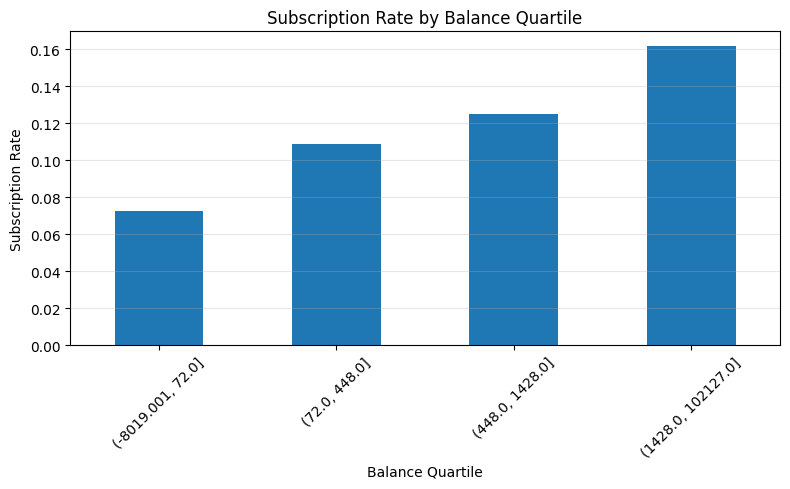

In [5]:

import pandas as pd
import matplotlib.pyplot as plt

# 1) Load dataset
df = pd.read_csv("../data/raw/bank-full.csv", sep=";")

# 2) Convert target to numeric
df["subscribed"] = df["y"].map({"yes": 1, "no": 0})

# 3) Create balance quartiles
df["balance_bin"] = pd.qcut(df["balance"], q=4, duplicates="drop")

# 4) Calculate subscription rate per quartile
conversion_by_bin = df.groupby("balance_bin")["subscribed"].mean()

# 5) Plot bar chart
plt.figure(figsize=(8, 5))
conversion_by_bin.plot(kind="bar")

plt.title("Subscription Rate by Balance Quartile")
plt.xlabel("Balance Quartile")
plt.ylabel("Subscription Rate")
plt.grid(axis="y", alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()


plt.show()

Question 2. Does having a housing loan affect subscription probability? 

#Insight
- Customers with housing loans have lower subscription rates.
- Housing loan status may help refine customer targeting.

Subscription rate by housing loan status:
housing
no     0.167024
yes    0.077000
Name: subscribed, dtype: float64


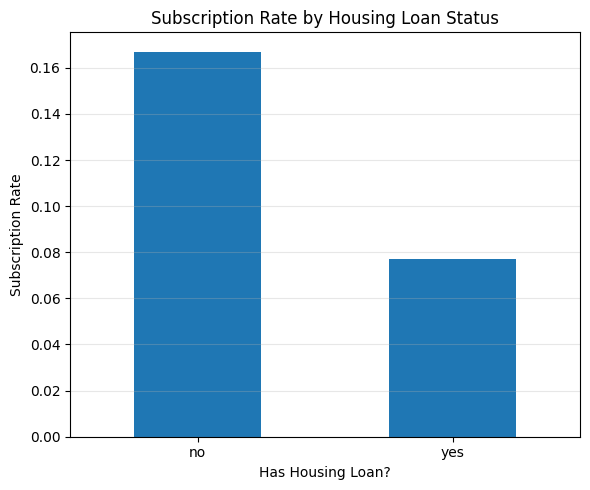

In [6]:
import pandas as pd
import matplotlib.pyplot as plt

# 1) Load dataset 
df = pd.read_csv("../data/raw/bank-full.csv", sep=";")

# 2) Convert subscription target to numeric (1 = yes, 0 = no)
df["subscribed"] = df["y"].map({"yes": 1, "no": 0})

# 3) Calculate subscription rate grouped by housing loan status
housing_conversion = df.groupby("housing")["subscribed"].mean()

print("Subscription rate by housing loan status:")
print(housing_conversion)

# 4) Create bar chart
plt.figure(figsize=(6, 5))
housing_conversion.plot(kind="bar")

plt.title("Subscription Rate by Housing Loan Status")
plt.xlabel("Has Housing Loan?")
plt.ylabel("Subscription Rate")
plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()

plt.show()

Question 3. Does having a personal loan affect subscription behavior?

#Insight
- Customers with personal loans show lower subscription rates.
- Existing debt may reduce likelihood of investing in term deposits.

Subscription rate by personal loan status:
loan
no     0.126557
yes    0.066814
Name: subscribed, dtype: float64


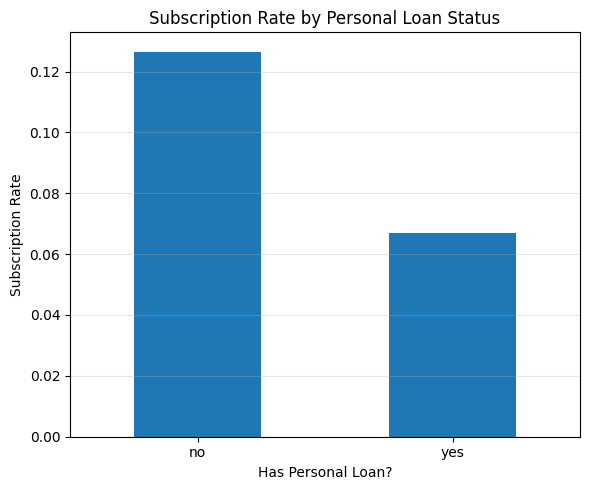

In [7]:
import pandas as pd
import matplotlib.pyplot as plt

# 1) Load dataset
df = pd.read_csv("../data/raw/bank-full.csv", sep=";")

# 2) Convert target to numeric
df["subscribed"] = df["y"].map({"yes": 1, "no": 0})

# 3) Calculate subscription rate by personal loan status
loan_conversion = df.groupby("loan")["subscribed"].mean()

print("Subscription rate by personal loan status:")
print(loan_conversion)

# 4) Create bar chart
plt.figure(figsize=(6, 5))
loan_conversion.plot(kind="bar")

plt.title("Subscription Rate by Personal Loan Status")
plt.xlabel("Has Personal Loan?")
plt.ylabel("Subscription Rate")
plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()

plt.show()


Question 4. Does having credit in default reduce subscription probability?

#Insights
- Customers with credit in default show significantly lower subscription rates.
- Credit risk status may be a strong indicator of low conversion probability.

Subscription rate by credit default status:
default
no     0.117961
yes    0.063804
Name: subscribed, dtype: float64


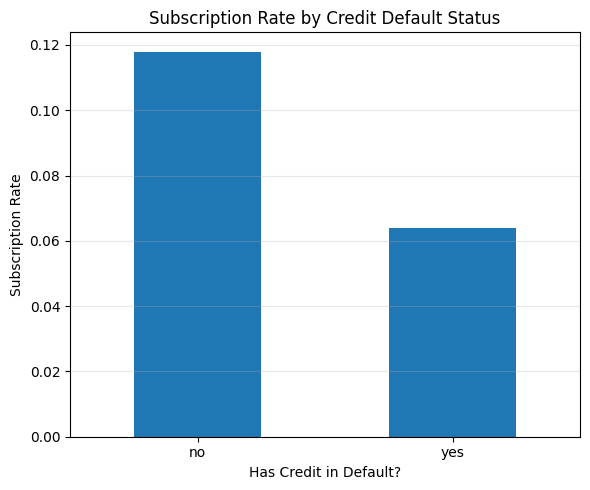

In [9]:
import pandas as pd
import matplotlib.pyplot as plt

# 1) Load dataset
df = pd.read_csv("../data/raw/bank-full.csv", sep=";")

# 2) Convert subscription target to numeric
df["subscribed"] = df["y"].map({"yes": 1, "no": 0})

# 3) Calculate subscription rates by default status
default_conversion = df.groupby("default")["subscribed"].mean()

print("Subscription rate by credit default status:")
print(default_conversion)

# 4) Create bar chart
plt.figure(figsize=(6, 5))
default_conversion.plot(kind="bar")

plt.title("Subscription Rate by Credit Default Status")
plt.xlabel("Has Credit in Default?")
plt.ylabel("Subscription Rate")
plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()

plt.show()

Question 5. Is there an interaction between balance and loan status?

#Insights

If strong interaction:
- High-balance customers without loans have the highest subscription rates.
- Loan status weakens the positive effect of higher balances.

If little interaction:
- Balance increases subscription probability regardless of loan status.
- Loan status does not significantly change the balance effect.

C:\Users\mjars\AppData\Local\Temp\ipykernel_5876\47479060.py:14: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  interaction = df.groupby(["balance_bin", "loan"])["subscribed"].mean().unstack()


Subscription rate by balance quartile and loan status:
loan                      no       yes
balance_bin                           
(-8019.001, 72.0]   0.076031  0.059571
(72.0, 448.0]       0.117660  0.066038
(448.0, 1428.0]     0.134785  0.069235
(1428.0, 102127.0]  0.170809  0.080380


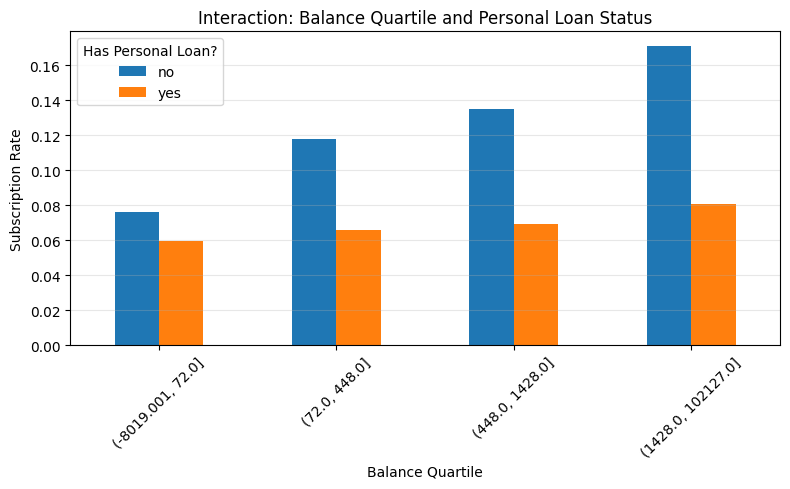

In [10]:
import pandas as pd
import matplotlib.pyplot as plt

# 1) Load dataset
df = pd.read_csv("../data/raw/bank-full.csv", sep=";")

# 2) Convertt target to numeric
df["subscribed"] = df["y"].map({"yes": 1, "no": 0})

# 3) Create balance quartiles
df["balance_bin"] = pd.qcut(df["balance"], q=4, duplicates="drop")

# 4) Group by balance quartile AND personal loan status
interaction = df.groupby(["balance_bin", "loan"])["subscribed"].mean().unstack()

print("Subscription rate by balance quartile and loan status:")
print(interaction)

# 5) Plot grouped bar chart
interaction.plot(kind="bar", figsize=(8,5))

plt.title("Interaction: Balance Quartile and Personal Loan Status")
plt.xlabel("Balance Quartile")
plt.ylabel("Subscription Rate")
plt.legend(title="Has Personal Loan?")
plt.xticks(rotation=45)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()


plt.show()

Question 6. Can subscription likelihood be linked to other products (e.g., loans)

#Insights
- Housing loans are significantly more common than personal loans in the dataset.
- Customer debt profile is dominated by housing obligations rather than personal loans.

Subscription rates for customers WITH each product:
                   Housing Loan (Yes)  Personal Loan (Yes)  \
Subscription Rate               0.077             0.066814   

                   Credit Default (Yes)  
Subscription Rate              0.063804  


<Figure size 700x500 with 0 Axes>

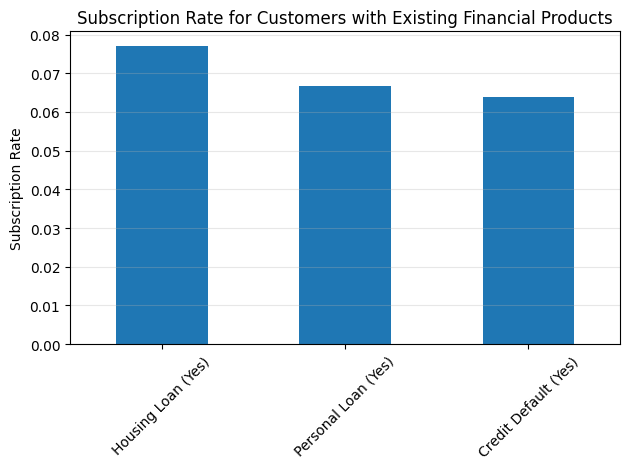

In [11]:
import pandas as pd
import matplotlib.pyplot as plt

# 1) Load dataset
df = pd.read_csv("../data/raw/bank-full.csv", sep=";")

# 2) Convert subscription to numeric
df["subscribed"] = df["y"].map({"yes": 1, "no": 0})

# 3) Calculated subscriptiond rates for each product type
housing_rate = df.groupby("housing")["subscribed"].mean()
personal_rate = df.groupby("loan")["subscribed"].mean()
default_rate = df.groupby("default")["subscribed"].mean()

# 4) Create a comparison table (only "yes" rows for clarity)
comparison = pd.DataFrame({
    "Housing Loan (Yes)": housing_rate["yes"],
    "Personal Loan (Yes)": personal_rate["yes"],
    "Credit Default (Yes)": default_rate["yes"]
}, index=["Subscription Rate"])

print("Subscription rates for customers WITH each product:")
print(comparison)

# 5) Bar chart comparison
plt.figure(figsize=(7,5))
comparison.T.plot(kind="bar", legend=False)

plt.title("Subscription Rate for Customers with Existing Financial Products")
plt.ylabel("Subscription Rate")
plt.xticks(rotation=45)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()

plt.show()

Question 7. How many loans are personal vs housing loans?

#Insights
- Housing loans are significantly more common than personal loans in the dataset.
- Customer debt profile is dominated by housing obligations rather than personal loans.

Housing loan counts:
housing
yes    25130
no     20081
Name: count, dtype: int64

Personal loan counts:
loan
no     37967
yes     7244
Name: count, dtype: int64

Loan comparison:
                     Housing Loans  Personal Loans
Number of Customers          25130            7244


<Figure size 600x500 with 0 Axes>

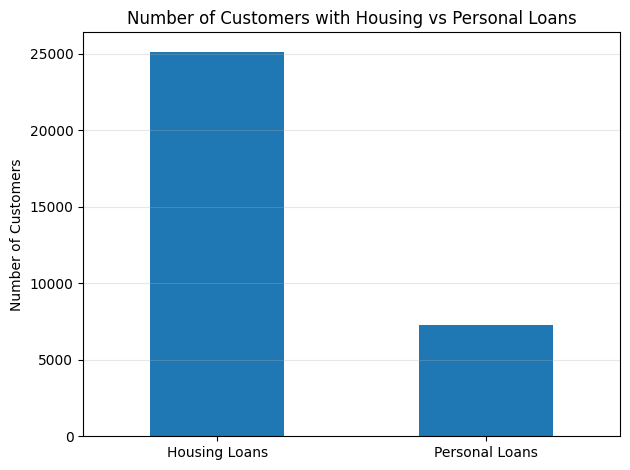

In [12]:
import pandas as pd
import matplotlib.pyplot as plt

# 1) Load dataset
df = pd.read_csv("../data/raw/bank-full.csv", sep=";")

# 2) Count housing loans
housing_counts = df["housing"].value_counts()

# 3) Count personal loans
personal_counts = df["loan"].value_counts()

print("Housing loan counts:")
print(housing_counts)

print("\nPersonal loan counts:")
print(personal_counts)

# 4) Create summary dataframe (only "yes" counts)
loan_summary = pd.DataFrame({
    "Housing Loans": housing_counts["yes"],
    "Personal Loans": personal_counts["yes"]
}, index=["Number of Customers"])

print("\nLoan comparison:")
print(loan_summary)

# 5) Bar chart comparison
plt.figure(figsize=(6,5))
loan_summary.T.plot(kind="bar", legend=False)

plt.title("Number of Customers with Housing vs Personal Loans")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()

plt.show()

Question 8. How much higher or richer does balance need to be to meaningfully increase subscription likelihood?

#Insights
- High income is considered $1,428


Balance Percentiles:
0.25      72.0
0.50     448.0
0.75    1428.0
Name: balance, dtype: float64

Subscription rate by balance quartile:
balance_bin
(-8019.001, 72.0]     0.072369
(72.0, 448.0]         0.108936
(448.0, 1428.0]       0.125155
(1428.0, 102127.0]    0.161547
Name: subscribed, dtype: float64

Top 25% balance threshold (75th percentile): € 1428.0


C:\Users\mjars\AppData\Local\Temp\ipykernel_5876\416737345.py:17: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  conversion_by_bin = df.groupby("balance_bin")["subscribed"].mean()


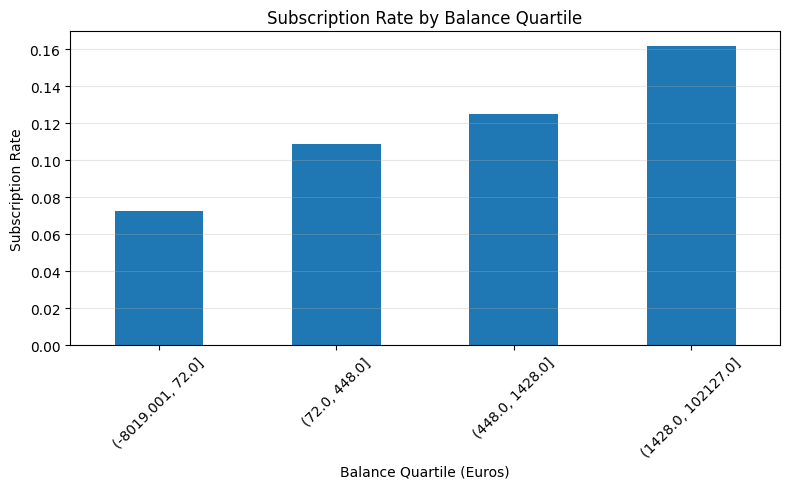

In [14]:
# 1) Load dataset
df = pd.read_csv("../data/raw/bank-full.csv", sep=";")

# 2) Convert target to numeric (1 = yes, 0 = no)
df["subscribed"] = df["y"].map({"yes": 1, "no": 0})

# 3) Calculate balance percentiles (these help us define what "high balance" means)
percentiles = df["balance"].quantile([0.25, 0.5, 0.75])

print("Balance Percentiles:")
print(percentiles)

# 4) Create balance quartiles (4 equal-sized groups)
df["balance_bin"] = pd.qcut(df["balance"], q=4, duplicates="drop")

# 5) Calculate subscription rate per quartile
conversion_by_bin = df.groupby("balance_bin")["subscribed"].mean()

print("\nSubscription rate by balance quartile:")
print(conversion_by_bin)

# 6) Identify threshold for top quartile
top_threshold = percentiles.loc[0.75]
print("\nTop 25% balance threshold (75th percentile): €", round(top_threshold, 2))

# 7) Bar chart comparison

plt.figure(figsize=(8, 5))
conversion_by_bin.plot(kind="bar")

plt.title("Subscription Rate by Balance Quartile")
plt.xlabel("Balance Quartile (Euros)")
plt.ylabel("Subscription Rate")
plt.grid(axis="y", alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

C. PREVIOUS CAMPAIGN EFFECTIVENESS

Question 1. How does the outcome of a previous campaign affect current success?

Key Variables: poutcome, y, subscribed

#Insights 
- Customers with previous campaign success have significantly higher subscription rates.
- Customers with previous campaign failure are much less likely to convert.
- Retargeting previously successful customers appears highly effective.


Subscription rate by previous campaign outcome:
poutcome
failure    0.126097
other      0.166848
success    0.647253
unknown    0.091615
Name: subscribed, dtype: float64


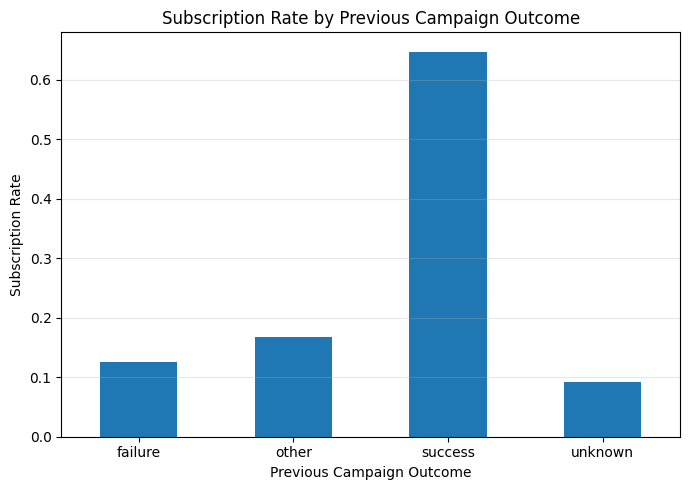

In [15]:
# 1) Load dataset
df = pd.read_csv("../data/raw/bank-full.csv", sep=";")

# 2) Convert subscription target to numeric
df["subscribed"] = df["y"].map({"yes": 1, "no": 0})

# 3) Calculate subscription rate grouped by previous campaign outcome
previous_outcome_conversion = df.groupby("poutcome")["subscribed"].mean()

print("Subscription rate by previous campaign outcome:")
print(previous_outcome_conversion)

# 4) Create bar chart
plt.figure(figsize=(7,5))
previous_outcome_conversion.plot(kind="bar")

plt.title("Subscription Rate by Previous Campaign Outcome")
plt.xlabel("Previous Campaign Outcome")
plt.ylabel("Subscription Rate")
plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()

plt.show()

Question 2. Are customers with previous successful campaigns more likely to subscribe again?

Key Variables: poutcome, y, subscribed

#Insights 
- Customers who previously subscribed are significantly more likely to subscribe again.
- Prior campaign success is one of the strongest predictors of current conversion.

Subscription rate comparison:
previous_success
No Previous Success    0.098650
Previous Success       0.647253
Name: subscribed, dtype: float64


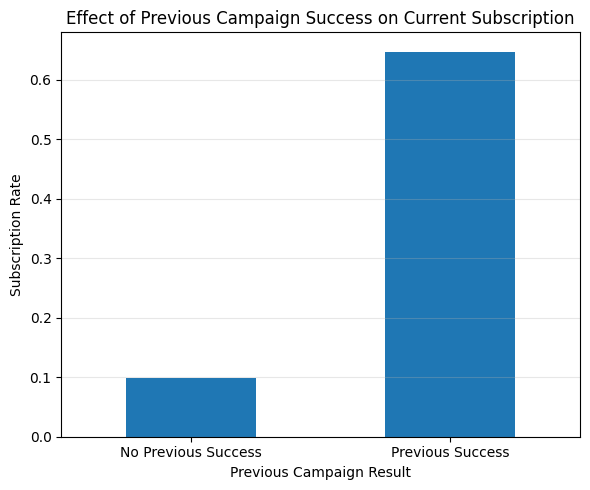

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# 1) Load dataset
df = pd.read_csv("../../../data/raw/bank-full.csv", sep=";")

# 2) Convert subscription target to numeric
df["subscribed"] = df["y"].map({"yes": 1, "no": 0})

# 3) Create a new column to isolate previous success vs others
df["previous_success"] = df["poutcome"].apply(
    lambda x: "Previous Success" if x == "success" else "No Previous Success"
)

# 4) Calculate subscription rate
success_conversion = df.groupby("previous_success")["subscribed"].mean()

print("Subscription rate comparison:")
print(success_conversion)

# 5) Plot bar chart
plt.figure(figsize=(6,5))
success_conversion.plot(kind="bar")

plt.title("Effect of Previous Campaign Success on Current Subscription")
plt.xlabel("Previous Campaign Result")
plt.ylabel("Subscription Rate")
plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()

plt.savefig("png_previouscampaign/02_previous_success_vs_subscription.png", dpi=300)

plt.show()

Question 3. Are customers with previous successful campaigns more likely to subscribe again?

Key Variables: poutcome, y, subscribed

#Insights 
- Customers who previously failed to subscribe show lower conversion rates in the current campaign.
- Repeatedly targeting previously unsuccessful customers may lead to diminishing returns.

Subscription rate comparison:
previous_failure
No Previous Failure    0.115877
Previous Failure       0.126097
Name: subscribed, dtype: float64


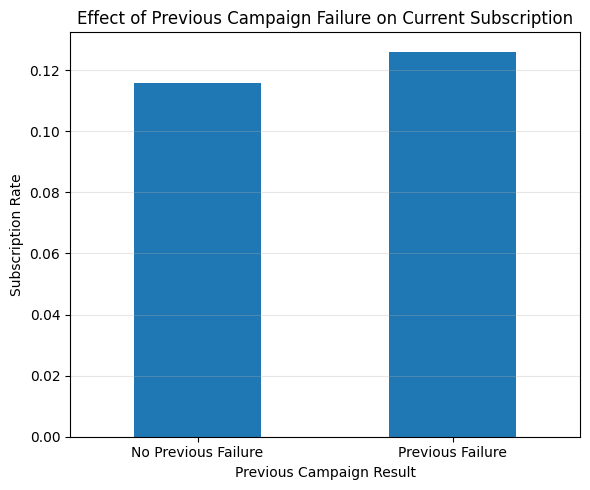

In [16]:
# 1) Load dataset
df = pd.read_csv("../data/raw/bank-full.csv", sep=";")

# 2) Convert subscription target to numeric
df["subscribed"] = df["y"].map({"yes": 1, "no": 0})

# 3) Create a new column to isolate previous failure vs others
df["previous_failure"] = df["poutcome"].apply(
    lambda x: "Previous Failure" if x == "failure" else "No Previous Failure"
)

# 4) Calculate subscription rate
failure_conversion = df.groupby("previous_failure")["subscribed"].mean()

print("Subscription rate comparison:")
print(failure_conversion)

# 5) Plot bar chart
plt.figure(figsize=(6,5))
failure_conversion.plot(kind="bar")

plt.title("Effect of Previous Campaign Failure on Current Subscription")
plt.xlabel("Previous Campaign Result")
plt.ylabel("Subscription Rate")
plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()

plt.show()

Question 4. Does time since last contact (pdays) influence success probability?

Key Variables: pdays, y, subscribed

#Insights 
- Customers contacted more recently show higher subscription rates.
- Subscription likelihood decreases as time since last contact increases.
- Recency appears to be an important driver of campaign effectiveness.

Subscription rate by pdays group:
pdays_group
0–30 Days          0.148936
31–90 Days         0.420755
90+ Days           0.219392
Never Contacted    0.091573
Name: subscribed, dtype: float64


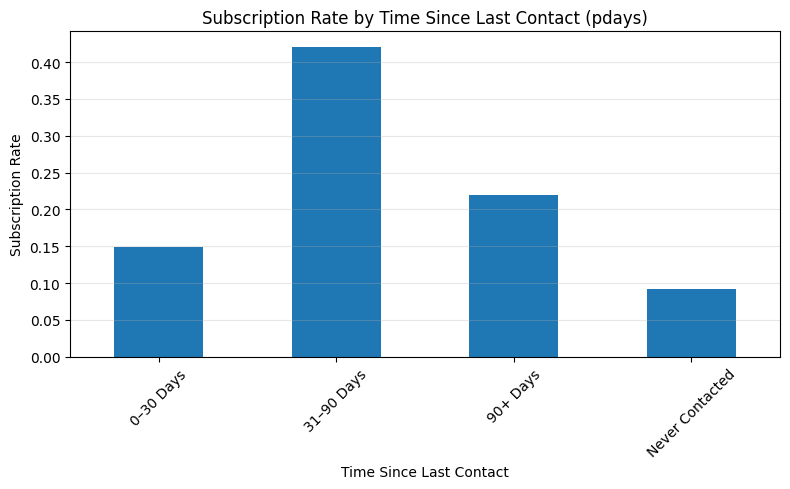

In [17]:
# 1) Load dataset
df = pd.read_csv("../data/raw/bank-full.csv", sep=";")

# 2) Convert subscription to numeric
df["subscribed"] = df["y"].map({"yes": 1, "no": 0})

# 3) Create pdays categories
def categorize_pdays(x):
    if x == -1:
        return "Never Contacted"
    elif x <= 30:
        return "0–30 Days"
    elif x <= 90:
        return "31–90 Days"
    else:
        return "90+ Days"

df["pdays_group"] = df["pdays"].apply(categorize_pdays)

# 4) Calculate subscription rate by pdays group
pdays_conversion = df.groupby("pdays_group")["subscribed"].mean()

print("Subscription rate by pdays group:")
print(pdays_conversion)

# 5) Plot bar chart
plt.figure(figsize=(8,5))
pdays_conversion.plot(kind="bar")

plt.title("Subscription Rate by Time Since Last Contact (pdays)")
plt.xlabel("Time Since Last Contact")
plt.ylabel("Subscription Rate")
plt.xticks(rotation=45)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()

plt.show()

Question 5. Are existing customers more likely to subscribe than new ones?

Key Variables: pdays, y, subscribed

#Insights 
- Existing customers generally show higher subscription rates than new customers.
- Prior engagement increases likelihood of conversion.
- Retargeting known customers may be more efficient than focusing only on new prospects.

Subscription rate by customer type:
customer_type
Existing Customer    0.230713
New Customer         0.091573
Name: subscribed, dtype: float64


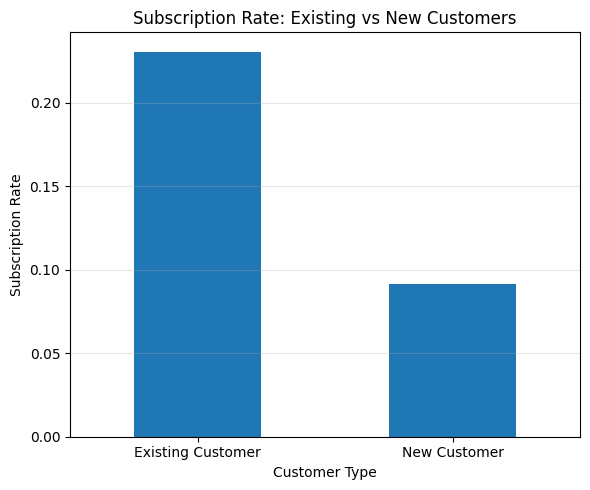

In [18]:
# 1) Load dataset
df = pd.read_csv("../data/raw/bank-full.csv", sep=";")

# 2) Convert subscription to numeric
df["subscribed"] = df["y"].map({"yes": 1, "no": 0})

# 3) Create customer type column
df["customer_type"] = df["pdays"].apply(
    lambda x: "Existing Customer" if x != -1 else "New Customer"
)

# 4) Calculate subscription rate
customer_conversion = df.groupby("customer_type")["subscribed"].mean()

print("Subscription rate by customer type:")
print(customer_conversion)

# 5) Plot bar chart
plt.figure(figsize=(6,5))
customer_conversion.plot(kind="bar")

plt.title("Subscription Rate: Existing vs New Customers")
plt.xlabel("Customer Type")
plt.ylabel("Subscription Rate")
plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()


plt.show()